# Proyecto Final UD2
#### UD2. Aprendizaxe Supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Vanesa Resúa Eiras, Cristina Gómez Alonso

En este proyecto, los alumnos del módulo de Machine Learning deberán demostrar los conocimientos adquiridos durante la UD2 y aplicar al menos dos algoritmos diferentes de aprendizaje supervisado vistos en clase (KNN, Regresión Lineal, Regresión Logística, Árboles de Decisión (o Randm Forest), SVM).

Para ello, tomaremos como referencia el dataset credit_train.csv y credit_test.csv que contienen la información sobre una campaña de márketing llevada a cabo mediante llamadas teléfonicas para captar clientes que quieran acceder a un crédito.

**Features o Input variables:**

1 - age: edad numérica

2 - job : tipo de trabajo (puede tomar los valores: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : estado civil (puede tomar los valores: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education : nivel de estudios (puede tomar los valores: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: ya tiene un crédito solicitado por defecto? (puede tomar los valores: 'no','yes','unknown')

6 - housing: tiene hipoteca? (puede tomar los valores: 'no','yes','unknown')

7 - loan: tiene una cuenta personal? (puede tomar los valores: 'no','yes','unknown')

8 - contact: tipo de comunicación de contacto (puede tomar los valores: 'cellular','telephone')

9 - month: último mes de contacto (puede tomar los valores: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10 - day_of_week: último día de la semana en el que se le ha contactado (puede tomar los valores: 'mon','tue','wed','thu','fri')

11 - duration: duración del último contacto en segundos (numérico). Importante: este atributo afecta en gran medida a la salida ya que si duration es 0, entonces  la salida es 'no')

12 - campaign: número de veces que se le ha contactado durante la campaña a este cliente (numérico, incluye el último contacto)

13 - pdays: número de días que han pasado desde que el cliente fue contactado por última vez(numérico; 999 significa que no ha sido contactado anteriormente)

14 - previous: número de contactos anteriores a esta campaña a este cliente(numérico)

15 - poutcome: resultado de la última campaña de marketing (categorical: 'failure','nonexistent','success')

16 - emp.var.rate: employment variation rate - quarterly indicator (numérico)

17 - cons.price.idx: IPC - indicador mensual (numérico)

18 - cons.conf.idx: índice de confianza de los consumidores - indicador mensual (numérico)

19 - euribor3m: euribor tasa 3 meses - indicador diario (numérico)

20 - nr.employed: número de trabajadores - indicador en porciones  (numérico)

**Output variable (desired target):**

21 - y: Suscripción al crédito por parte del cliente? (binary: 'yes','no')

Los requisitos mínimos de este proyecto consisten en:

* Etapas comunes 1, 2 y 3 de importación, análisis numérico y visual, así como preprocesado.
* Para cada algoritmo que apliques deberás de mantener la siguiente estructura de 5 etapas (del 4-8), pero puedes añadir subapartados o etapas adicionales.
* En cada etapa se deben añadir explicaciones justificativas de lo que se quiere hacer, así como de los resultados obtenidos.
* Como resultado final, se deben contrastar los resultados obtenidos y comparar los algoritmos utilizados indicando claramente cual y porqué obtiene mejor resultados.

Cualificaciones:
- Uso de 2 algoritmos: cualificación máxima de 7 puntos
- Uso de 3 algoritmos: cualificación máxima de 10 puntos.




## 1. Importación de paquetes y dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sb
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree


In [2]:
df = pd.read_csv("credit-train.csv") 

Importación del dataset

## 2.EDA y Visual EDA

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [5]:
df.describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
10%,28.00000,59.000000,1.000000,999.000000,0.000000,-1.800000,92.893000,-46.200000,1.046000,5076.200000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
90%,55.00000,551.000000,5.000000,999.000000,1.000000,1.400000,94.465000,-36.100000,4.964000,5228.100000,1.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
def create_graphics_categorical(columns):
    fig, axes = plt.subplots(4, 3, figsize=(18, 16))  
    axes = axes.flatten()  

    for i, col in enumerate(columns[:-1]):  
        if i < len(axes):
            sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, hue='y', palette='Set2')
            axes[i].set_title(f'{col} - y', fontsize=14)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('Count')
            axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    
    for i in range(len(columns) - 1, len(axes)):  
        fig.delaxes(axes[i]) 
    
    plt.tight_layout()
    plt.show()  

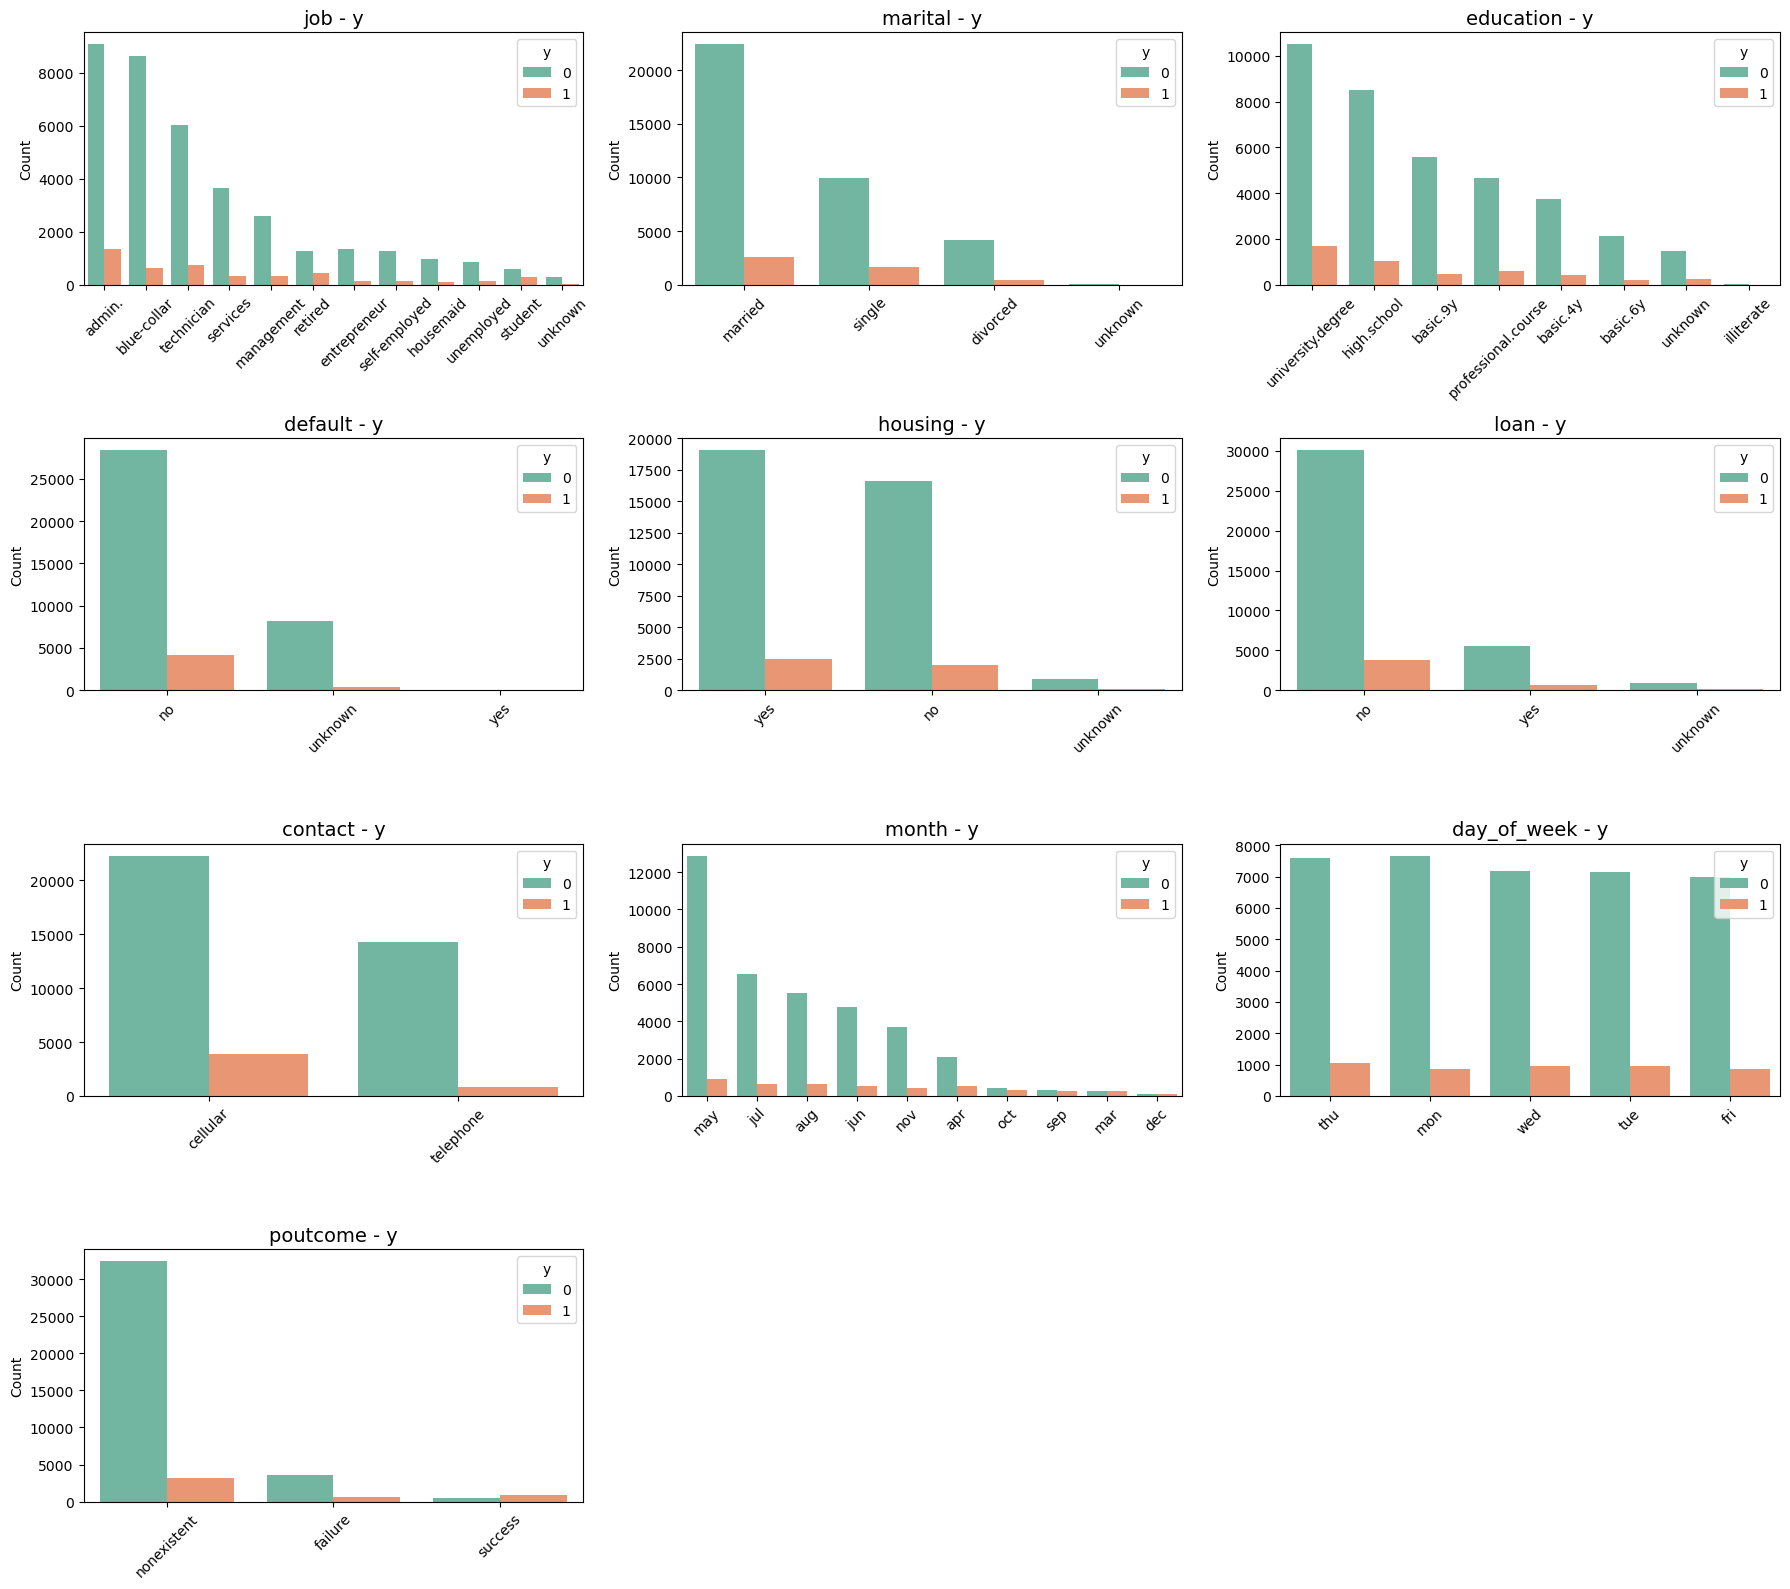

In [8]:
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 
                       'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

create_graphics_categorical(categorical_columns)

In [9]:

def create_graphics_continuous(columns):
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols  

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.boxplot(data=df, x='y', y=col, ax=axes[i])
        axes[i].set_title(f'Distribución de {col} según Y')
        axes[i].tick_params(axis='x', rotation=45)  

    for i in range(len(columns), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

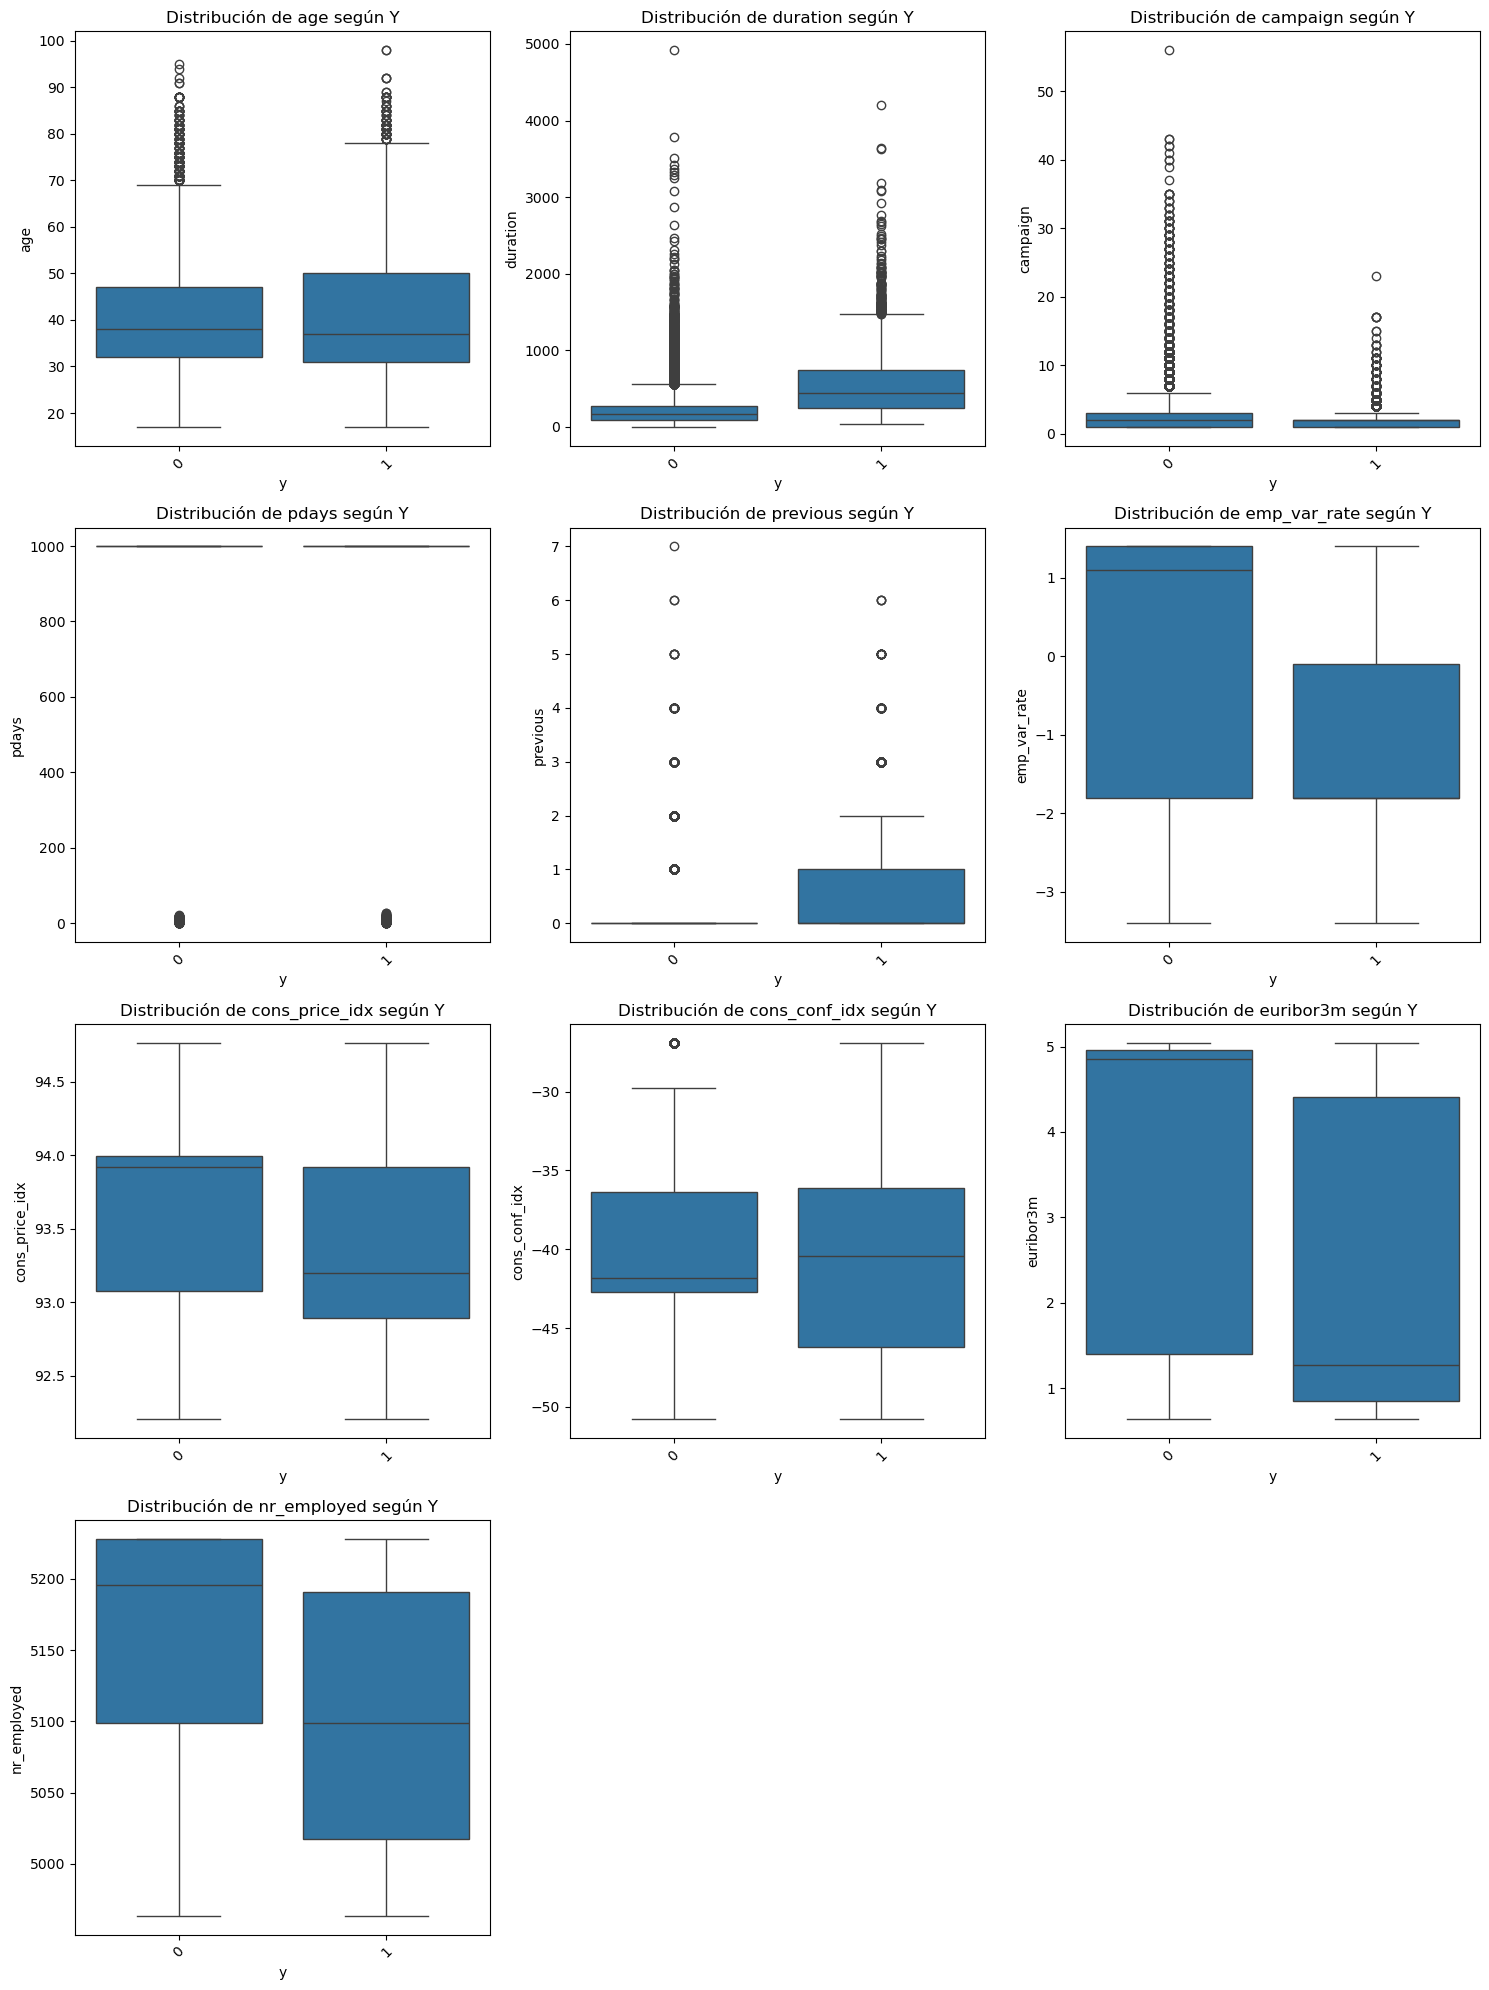

In [10]:
continuous_columns = ['age', 'duration', 'campaign', 'pdays', 'previous', 
                      'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 
                      'euribor3m', 'nr_employed']

create_graphics_continuous(continuous_columns)

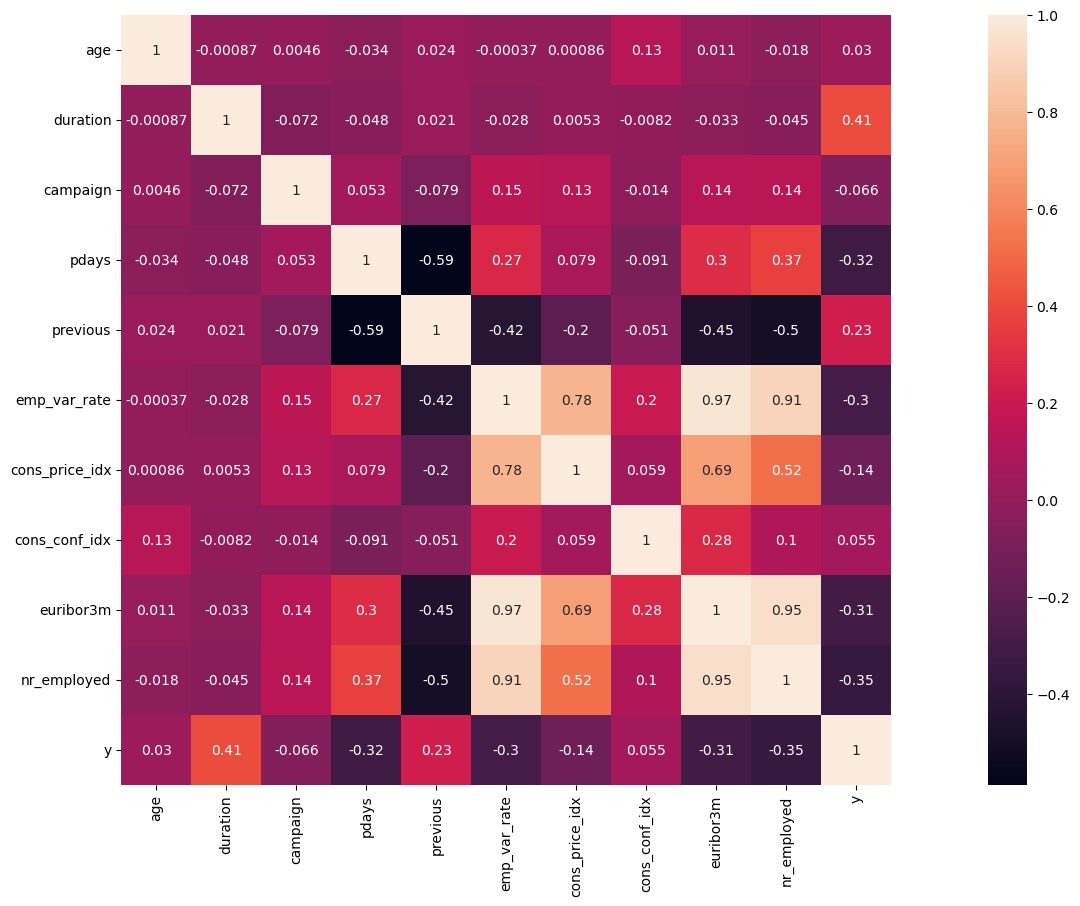

In [11]:
df_numeric = df.select_dtypes(include=["number"])
correlation=df_numeric.corr(method="pearson")
plt.figure(figsize=(25,10))
sns.heatmap(correlation,vmax=1,square=True,annot=True)
plt.show()

## 3. Preprocessing data


In [12]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

Ahora, decido borrar las siguientes columnas ya que para captar clientes no tienen relevancia. Aparte de esto, los datos no son significativos.

In [13]:
df=df.drop(["pdays","month","day_of_week","contact","nr_employed"],axis=1)

Pasamos a numericos las columnas que lo necesiten.

In [14]:
categorical_features = df.iloc[:, :-1].select_dtypes(include=['object']).columns
label_encoder = LabelEncoder ()

for col in categorical_features:
    df[col] = label_encoder.fit_transform(df[col])

df

,age,job,marital,education,default,housing,loan,duration,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,y
0,44,1,1,0,1,2,0,210,1,0,1,1.4,93.444,-36.1,4.963,0
1,53,9,1,7,0,0,0,138,1,0,1,-0.1,93.200,-42.0,4.021,0
2,28,4,2,6,0,2,0,339,3,2,2,-1.7,94.055,-39.8,0.729,1
3,39,7,1,3,0,0,0,185,2,0,1,-1.8,93.075,-47.1,1.405,0
4,55,5,1,0,0,2,0,137,1,1,2,-2.9,92.201,-31.4,0.869,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59,5,1,3,1,0,2,222,1,0,1,1.4,94.465,-41.8,4.866,0
41184,31,3,1,0,1,0,0,196,2,0,1,1.1,93.994,-36.4,4.860,0
41185,42,0,2,6,1,2,2,62,3,0,1,1.1,93.994,-36.4,4.857,0
41186,48,9,1,5,0,0,2,200,2,0,1,-3.4,92.431,-26.9,0.742,0


In [15]:
X = df.drop('y', axis=1).values
y = df['y'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)



<h3>Preparación de datos para credit-test</h3>

In [16]:
dt = pd.read_csv("credit-test.csv")
dt = dt.drop(["pdays","month","day_of_week","contact","nr_employed"],axis=1)

categorical_features = dt.iloc[:, :-1].select_dtypes(include=['object']).columns
label_encoder = LabelEncoder ()

for col in categorical_features:
    dt[col] = label_encoder.fit_transform(dt[col])

dt_nuevo_scaler =  scaler.transform(dt)

dt

/home/lloves/miniconda3/envs/machine-learning/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


,age,job,marital,education,default,housing,loan,duration,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m
0,30,1,1,2,0,2,0,487,2,0,1,-1.8,92.893,-46.2,1.313
1,39,7,2,3,0,0,0,346,4,0,1,1.1,93.994,-36.4,4.855
2,25,7,1,3,0,2,0,227,1,0,1,1.4,94.465,-41.8,4.962
3,38,7,1,2,0,1,1,17,3,0,1,1.4,94.465,-41.8,4.959
4,47,0,1,6,0,2,0,58,1,0,1,-0.1,93.200,-42.0,4.191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,0,1,1,0,2,2,53,1,0,1,1.4,93.918,-42.7,4.958
4115,39,0,1,3,0,2,0,219,1,0,1,1.4,93.918,-42.7,4.959
4116,27,8,2,3,0,0,0,64,2,1,0,-1.8,92.893,-46.2,1.354
4117,58,0,1,3,0,0,0,528,1,0,1,1.4,93.444,-36.1,4.966


<h1 style="color: red; font-size: 50px;">KNN</h1>


## 4. Creación del modelo y división del dataset

Calculo del mejor K

([<matplotlib.axis.XTick at 0x7c0d00ea0fa0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20')])

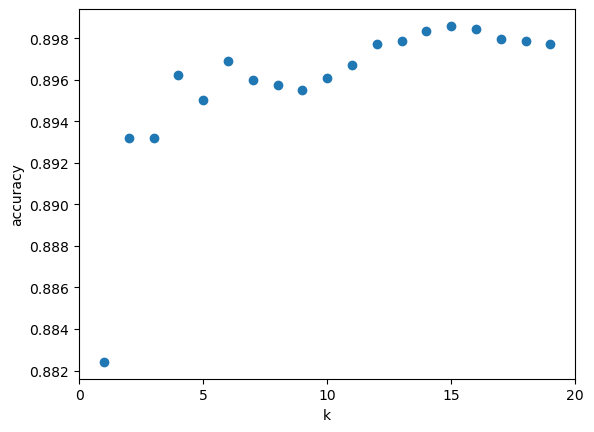

In [17]:
k_range = range(1, 20)

scores = []
for k in k_range:
      knn = KNeighborsClassifier(n_neighbors = k)
      knn.fit(X_train, y_train)
      scores.append(knn.score(X_test, y_test))

plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20])

In [18]:
n_neighbors = 15

knn = KNeighborsClassifier(n_neighbors)

## 5. Entrenamiento

In [19]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

## 6. Análisis de resultados

In [20]:
print('Accuracy of K-NN classifier on training set: {:.2f}'
      .format(knn.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
      .format(knn.score(X_test, y_test)))

Accuracy of K-NN classifier on training set: 0.90
Accuracy of K-NN classifier on test set: 0.90


Estos resultados indican que el modelo está bien ajustado y ofrece una buena capacidad de generalización.

In [21]:
pred = knn.predict(X_test)

cm = confusion_matrix(y_test, pred)
print("-------Matriz de confusión---------\n")
print(cm) 


print("\n-------Métricas clave--------------\n")
print(classification_report(y_test, pred))

-------Matriz de confusión---------

[[10792   173]
 [ 1080   312]]

-------Métricas clave--------------

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10965
           1       0.64      0.22      0.33      1392

    accuracy                           0.90     12357
   macro avg       0.78      0.60      0.64     12357
weighted avg       0.88      0.90      0.88     12357



## 7. Realización de predicciones

In [22]:
pred = knn.predict(dt_nuevo_scaler)
print(pred[:50])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0]
Porcentaje de 0: 95.44%
Porcentaje de 1: 4.56%


In [ ]:
percent_0 = np.mean(pred == 0) * 100
percent_1 = np.mean(pred == 1) * 100

print(f"Porcentaje de 0: {percent_0:.2f}%")
print(f"Porcentaje de 1: {percent_1:.2f}%")

## 8. Visualización

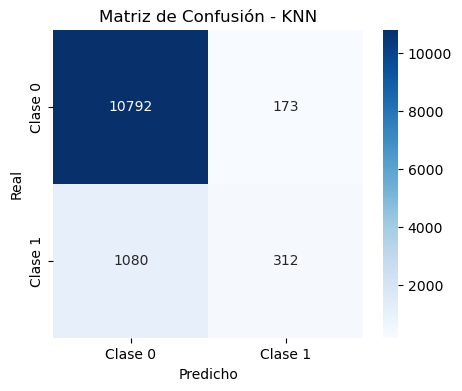

In [23]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - KNN")
plt.show()

En la matriz de confusión vemos que el modelo tiene dificultades para detectar la clase 1, también que tenemos una desigualdad de datos (muchos mas datos de la clase 0)

<h1 style="color: red; font-size: 50px;">LOGISTIC REGRESION</h1>

## 4. Creación del modelo y división del dataset

In [24]:
clf1 = LogisticRegression(penalty='l2')

## 5. Entrenamiento

In [25]:
clf1.fit(X_train,y_train)

LogisticRegression()

## 6. Análisis de resultados

In [26]:
print('Score: {}'.format(clf1.score(X_test, y_test)))

print("-------Matriz de confusión---------\n")
mc_clf1 = confusion_matrix(y_test, clf1.predict(X_test))
print(mc_clf1)

Score: 0.9083110787407946
-------Matriz de confusión---------

[[10749   216]
 [  917   475]]


In [27]:
print("\n-------Métricas clave--------------\n")
print(classification_report(y_test, clf1.predict(X_test)))


-------Métricas clave--------------

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10965
           1       0.69      0.34      0.46      1392

    accuracy                           0.91     12357
   macro avg       0.80      0.66      0.70     12357
weighted avg       0.90      0.91      0.89     12357



## 7. Realización de predicciones

In [28]:
pred = clf1.predict(dt_nuevo_scaler)
print(pred[:50])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Porcentaje de 0: 94.32%
Porcentaje de 1: 5.68%


In [ ]:
percent_0 = np.mean(pred == 0) * 100
percent_1 = np.mean(pred == 1) * 100

print(f"Porcentaje de 0: {percent_0:.2f}%")
print(f"Porcentaje de 1: {percent_1:.2f}%")

## 8. Visualización

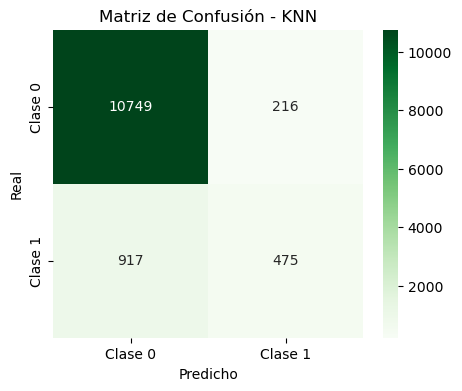

In [29]:
plt.figure(figsize=(5,4))
sns.heatmap(mc_clf1, annot=True, fmt="d", cmap="Greens", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - KNN")
plt.show()

<h1 style="color: red; font-size: 50px;">RANDOM FOREST</h1>

## 4. Creación del modelo y división del dataset

In [30]:
crf = RandomForestClassifier(n_estimators=100, criterion='gini', max_features='sqrt' , max_samples=None, random_state=2)

## 5. Entrenamiento

In [31]:
crf.fit(X_train, y_train)

RandomForestClassifier(random_state=2)

## 6. Analisis de resultado

In [32]:
print('Score: {}'.format(clf1.score(X_test, y_test)))

print("-------Matriz de confusión---------\n")
print(confusion_matrix(y_test, clf1.predict(X_test)))

Score: 0.9083110787407946
-------Matriz de confusión---------

[[10749   216]
 [  917   475]]


In [33]:
print("\n-------Métricas clave--------------\n")
print(classification_report(y_test, crf.predict(X_test)))


-------Métricas clave--------------

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     10965
           1       0.65      0.49      0.56      1392

    accuracy                           0.91     12357
   macro avg       0.79      0.73      0.76     12357
weighted avg       0.91      0.91      0.91     12357



In [34]:
print("Precisión en conjunto de datos de entrenamiento: {:.3f}".format(crf.score(X_train, y_train)))
print("Precisión en el conjunto de datos de evaluación: {:.3f}".format(crf.score(X_test, y_test)))

Precisión en conjunto de datos de entrenamiento: 1.000
Precisión en el conjunto de datos de evaluación: 0.913


## 7. Realización de predicciones

In [35]:
print("--Ejemplo de salida tras una predicción--")

pred = crf.predict(dt_nuevo_scaler)
print(pred[:50])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Porcentaje de 0: 89.54%
Porcentaje de 1: 10.46%


In [ ]:

percent_0 = np.mean(pred == 0) * 100
percent_1 = np.mean(pred == 1) * 100

print(f"Porcentaje de 0: {percent_0:.2f}%")
print(f"Porcentaje de 1: {percent_1:.2f}%")

Aqui vemos el porcentaje de 0's y de 1's, una gran desigualdad.

## 8. Visualización

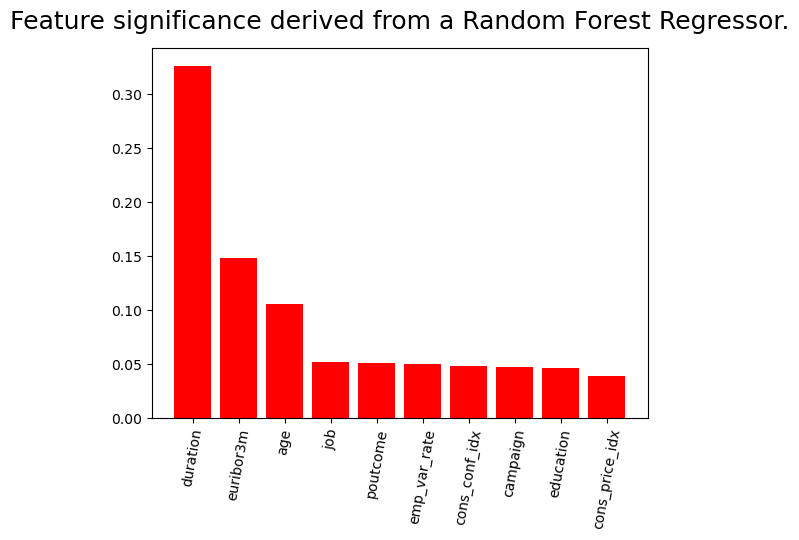

In [36]:
ranking = crf.feature_importances_
features = np.argsort(ranking)[::-1][:10]
columns = df.columns
plt.title("Feature significance derived from a Random Forest Regressor.", y = 1.03, size = 18)
plt.bar(range(len(features)), ranking[features], color="red", align="center")
plt.xticks(range(len(features)), columns[features], rotation=80)
plt.show()

Vemos que la duración es la variable más importante, esto significa que influye significativamente en la predicción. Cuanto mayor es la duración, más clientes se captan.
También, el euribor3m(tasa de interés a 3 meses) tiene una buena importancia, esto sugiere que las condiciones economicas afectan al resultado, al igual que la edad.
Las demás tienen un menor peso en las predicciones.

Comparación de los algoritmos (KNN, Regresión Logística y Random Forest)

Analizando las métricas clave de cada modelo (precisión, recall, F1-score y exactitud), se pueden extraer varias conclusiones sobre su desempeño en la clasificación:

**K-Nearest Neighbors (KNN):**  
Ventajas: Tiene una buena precisión para la clase mayoritaria (0), pero su recall para la clase minoritaria (1) es bastante bajo (0.22). Esto indica que no detecta bien los casos positivos.  
Desventajas: El modelo tiene problemas con el balance de clases y no predice bien la clase minoritaria, lo que afecta la generalización.  

**Regresión Logística:**  
Ventajas: Mejora el recall de la clase minoritaria (0.34), lo que significa que detecta más positivos en comparación con KNN. Además, la precisión y el F1-score también son mejores.  
Desventajas: Aunque mejora el rendimiento general, aún tiene dificultades para clasificar correctamente la clase minoritaria.  

**Random Forest:**   
Ventajas: Es el modelo con mejor rendimiento general. Su recall para la clase 1 (0.49) es significativamente superior a los otros modelos, lo que indica que detecta más instancias positivas sin comprometer demasiado la precisión. Además, la métrica F1-score de la clase minoritaria es la más alta (0.56), lo que muestra un mejor equilibrio entre precisión y recall.  
Desventajas: Aunque tiene un mayor costo computacional en comparación con la regresión logística, su rendimiento lo justifica.

Conclusión Final:

El mejor modelo es Random Forest, ya que logra el mejor equilibrio entre precisión y recall, especialmente para la clase minoritaria. Mientras que KNN tiene un recall muy bajo y la regresión logística mejora ligeramente el desempeño, Random Forest demuestra ser el más efectivo en la tarea de clasificación con una precisión y recall más balanceados.

Si el objetivo es maximizar la detección de la clase minoritaria sin perder precisión en la clase mayoritaria, Random Forest es la mejor opción.
